<>:14: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:14: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\tangb\AppData\Local\Temp\ipykernel_44180\1572293898.py:14: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df = pd.read_csv('..\data\cookie_cats.csv\cookie_cats.csv')


=== A/B 그룹 기본 현황 ===
gate_30 유저 수: 44,700
gate_40 유저 수: 45,489

gate_30 D1 리텐션: 0.448
gate_40 D1 리텐션: 0.442

gate_30 D7 리텐션: 0.190
gate_40 D7 리텐션: 0.182

=== D1 리텐션 카이제곱 검정 ===
retention_1  False  True 
version                  
gate_30      24666  20034
gate_40      25370  20119

chi2 통계량: 3.1591
p-value: 0.0755
결론: 유의미한 차이 없음 ❌

=== D7 리텐션 카이제곱 검정 ===
retention_7  False  True 
version                  
gate_30      36198   8502
gate_40      37210   8279

chi2 통계량: 9.9591
p-value: 0.0016
결론: 유의미한 차이 있음 ✅

=== D7 리텐션 95% 신뢰구간 ===
gate_30: 0.190 (0.187 ~ 0.194)
gate_40: 0.182 (0.178 ~ 0.186)


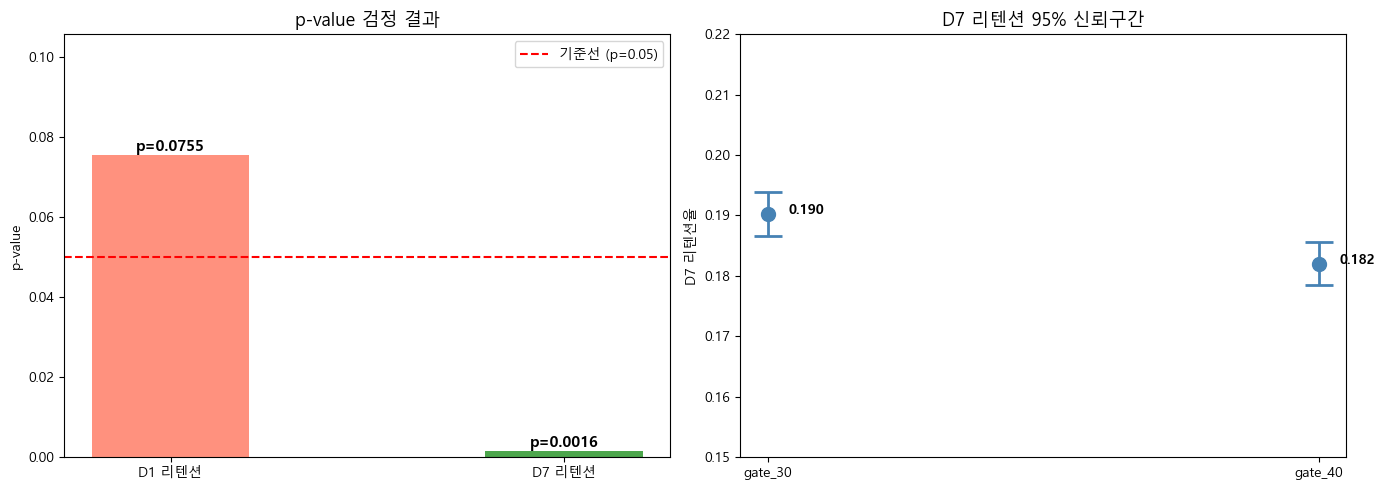

In [ ]:
# 04_ab_test.ipynb

# =====================
# 1. 라이브러리 로드
# =====================
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

df = pd.read_csv('..\data\cookie_cats.csv\cookie_cats.csv')

# =====================
# 2. 기본 현황 확인
# =====================
gate_30 = df[df['version'] == 'gate_30']
gate_40 = df[df['version'] == 'gate_40']

print("=== A/B 그룹 기본 현황 ===")
print(f"gate_30 유저 수: {len(gate_30):,}")
print(f"gate_40 유저 수: {len(gate_40):,}")
print(f"\ngate_30 D1 리텐션: {gate_30['retention_1'].mean():.3f}")
print(f"gate_40 D1 리텐션: {gate_40['retention_1'].mean():.3f}")
print(f"\ngate_30 D7 리텐션: {gate_30['retention_7'].mean():.3f}")
print(f"gate_40 D7 리텐션: {gate_40['retention_7'].mean():.3f}")

# =====================
# 3. 카이제곱 검정
# 리텐션은 True/False 데이터라서
# t-test 대신 카이제곱 검정
# =====================
print("\n=== D1 리텐션 카이제곱 검정 ===")

# D1 교차표 만들기
d1_crosstab = pd.crosstab(df['version'], df['retention_1'])
print(d1_crosstab)

chi2_d1, p_d1, dof, expected = stats.chi2_contingency(d1_crosstab)
print(f"\nchi2 통계량: {chi2_d1:.4f}")
print(f"p-value: {p_d1:.4f}")
print(f"결론: {'유의미한 차이 있음 ✅' if p_d1 < 0.05 else '유의미한 차이 없음 ❌'}")

print("\n=== D7 리텐션 카이제곱 검정 ===")

# D7 교차표 만들기
d7_crosstab = pd.crosstab(df['version'], df['retention_7'])
print(d7_crosstab)

chi2_d7, p_d7, dof, expected = stats.chi2_contingency(d7_crosstab)
print(f"\nchi2 통계량: {chi2_d7:.4f}")
print(f"p-value: {p_d7:.4f}")
print(f"결론: {'유의미한 차이 있음 ✅' if p_d7 < 0.05 else '유의미한 차이 없음 ❌'}")

# =====================
# 4. 신뢰구간 계산
# "진짜 차이가 어느 범위 안에 있나?"
# =====================
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = data.mean()
    se = stats.sem(data)
    margin = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean, mean - margin, mean + margin

mean_30, lo_30, hi_30 = confidence_interval(gate_30['retention_7'])
mean_40, lo_40, hi_40 = confidence_interval(gate_40['retention_7'])

print("\n=== D7 리텐션 95% 신뢰구간 ===")
print(f"gate_30: {mean_30:.3f} ({lo_30:.3f} ~ {hi_30:.3f})")
print(f"gate_40: {mean_40:.3f} ({lo_40:.3f} ~ {hi_40:.3f})")

# =====================
# 5. 시각화
# =====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 왼쪽: p-value 시각화 ---
tests = ['D1 리텐션', 'D7 리텐션']
p_values = [p_d1, p_d7]
colors = ['green' if p < 0.05 else 'tomato' for p in p_values]

bars = axes[0].bar(tests, p_values, color=colors, alpha=0.7, width=0.4)
axes[0].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='기준선 (p=0.05)')
axes[0].set_title('p-value 검정 결과', fontsize=13)
axes[0].set_ylabel('p-value')
axes[0].set_ylim(0, max(p_values) * 1.4)
axes[0].legend()

for bar, p in zip(bars, p_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'p={p:.4f}', ha='center', fontweight='bold', fontsize=11)

# --- 오른쪽: 신뢰구간 시각화 ---
groups = ['gate_30', 'gate_40']
means = [mean_30, mean_40]
errors_lo = [mean_30 - lo_30, mean_40 - lo_40]
errors_hi = [hi_30 - mean_30, hi_40 - mean_40]

axes[1].errorbar(groups, means,
                 yerr=[errors_lo, errors_hi],
                 fmt='o', color='steelblue',
                 capsize=10, capthick=2,
                 markersize=10, linewidth=2)
axes[1].set_title('D7 리텐션 95% 신뢰구간', fontsize=13)
axes[1].set_ylabel('D7 리텐션율')
axes[1].set_ylim(0.15, 0.22)

for g, m in zip(groups, means):
    axes[1].annotate(f'{m:.3f}', (g, m),
                     textcoords='offset points',
                     xytext=(15, 0), fontweight='bold')

plt.tight_layout()
plt.savefig('../images/ab_test_result.png')
plt.show()